In [7]:
import numpy as np
import pandas as pd

In [8]:
df = pd.read_csv("diabetes.csv")

In [9]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

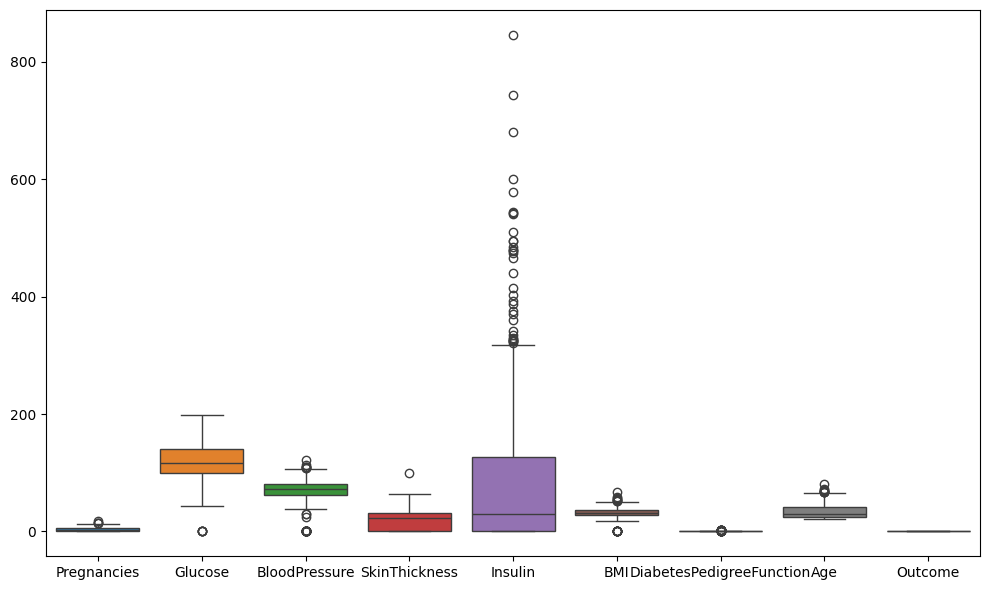

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(df)
plt.tight_layout()

C:\Users\user\AppData\Local\Temp\ipykernel_18512\2365973029.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Insulin'])
C:\Users\user\AppData\Local\Temp\ipykernel_18512\2365973029.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['BMI'])


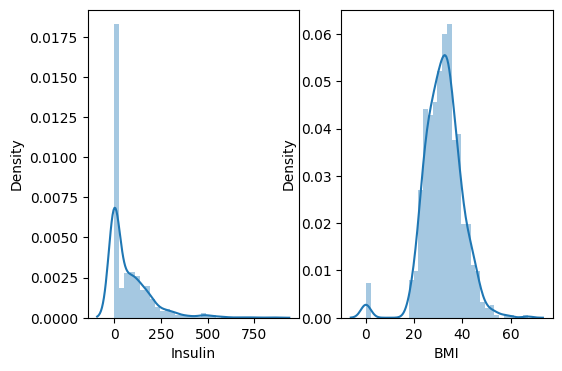

In [14]:
plt.figure(figsize=(6,4))

plt.subplot(1,2,1)
sns.distplot(df['Insulin'])

plt.subplot(1,2,2)
sns.distplot(df['BMI'])

plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [16]:
from sklearn.preprocessing import StandardScaler,RobustScaler

In [17]:
X = df.drop('Outcome',axis=1)
y = df['Outcome']

In [18]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
preprocess = ColumnTransformer(
    transformers=
    [
        ("std",StandardScaler(),['Pregnancies',	'Glucose','BloodPressure','SkinThickness','BMI','DiabetesPedigreeFunction',	'Age']),
        ("Robust",RobustScaler(),['Insulin'])
    ],
    remainder='passthrough'
)

In [20]:
from sklearn.naive_bayes import GaussianNB

In [21]:
model = GaussianNB()

In [22]:
main_pipeline = Pipeline(
    steps=[
        ("pre",preprocess),
        ("model",GaussianNB())
    ]
)

In [23]:
main_pipeline.fit(x_train,y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('std', StandardScaler(),
                                                  ['Pregnancies', 'Glucose',
                                                   'BloodPressure',
                                                   'SkinThickness', 'BMI',
                                                   'DiabetesPedigreeFunction',
                                                   'Age']),
                                                 ('Robust', RobustScaler(),
                                                  ['Insulin'])])),
                ('model', GaussianNB())])

In [24]:
y_pred_test = main_pipeline.predict(x_test)
y_pred_train = main_pipeline.predict(x_train)

In [25]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,confusion_matrix

In [26]:
print(accuracy_score(y_test,y_pred_test))

0.7662337662337663


In [27]:
print(accuracy_score(y_train,y_pred_train))

0.752442996742671


In [28]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154

